# Construction Site PPE Monitoring

This notebook contains the complete project workflow and all results are displayed inline. No external PDF or report files are required for submission.

Sections:
1. Dataset download and sanity checks
2. Dataset discovery and YAML creation
3. Model training and evaluation
4. Video monitoring and compliance analysis
5. Results summary (inline)
6. Optional Streamlit demo


In [1]:
# =========================
# Cell — Download & Prepare Construction-PPE (Ultralytics) + Quick Sanity Check
# =========================
import os, subprocess, random
from pathlib import Path
import glob

# --- Paths (robust even لو المتغيرات مش موجودة) ---
ROOT = Path("/content/safety_ppe_project")
RAW  = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RAW :", RAW)
print("PROC:", PROC)

# --- Official dataset zip from Ultralytics assets (Construction-PPE) ---
URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip"
ZIP_PATH = RAW / "construction-ppe.zip"

# Download (only if missing/suspiciously small)
need_dl = (not ZIP_PATH.exists()) or (ZIP_PATH.stat().st_size < 1_000_000)
if need_dl:
    print("\nDownloading:", URL)
    subprocess.run(["wget", "-q", "-O", str(ZIP_PATH), URL], check=True)
else:
    print("\nZip already exists:", ZIP_PATH, "size =", ZIP_PATH.stat().st_size)

print("Zip size (bytes):", ZIP_PATH.stat().st_size)

# Unzip to PROC
print("\nUnzipping...")
subprocess.run(["rm", "-rf", str(PROC / "construction-ppe")], check=False)
subprocess.run(["unzip", "-q", str(ZIP_PATH), "-d", str(PROC)], check=True)

DATA_DIR = PROC / "construction-ppe"
print("DATA_DIR:", DATA_DIR, "| exists:", DATA_DIR.exists())

# Find yaml inside dataset (usually construction-ppe.yaml)
yaml_candidates = list(DATA_DIR.glob("*.yaml")) + list(DATA_DIR.glob("*.yml"))
print("\nYAML files found:", [p.name for p in yaml_candidates])

# Basic counts
def count_imgs_labels(split):
    img_dir = DATA_DIR / "images" / split
    lbl_dir = DATA_DIR / "labels" / split
    imgs = []
    for ext in ("*.jpg","*.jpeg","*.png","*.bmp","*.webp"):
        imgs += list(img_dir.glob(ext))
    lbls = list(lbl_dir.glob("*.txt"))
    return len(imgs), len(lbls), img_dir, lbl_dir

print("\n=== Split Counts ===")
for s in ["train", "val", "test"]:
    ni, nl, img_dir, lbl_dir = count_imgs_labels(s)
    print(f"{s:5s} | images: {ni:5d} | labels: {nl:5d} | img_dir: {img_dir}")

# Quick label sanity (count boxes & classes from train)
train_lbl_dir = DATA_DIR / "labels" / "train"
class_counts = {}
total_boxes = 0
for p in list(train_lbl_dir.glob("*.txt"))[:5000]:  # cap to keep it fast
    lines = [ln.strip() for ln in p.read_text().splitlines() if ln.strip()]
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 5:
            c = int(float(parts[0]))
            class_counts[c] = class_counts.get(c, 0) + 1
            total_boxes += 1

print("\nTotal boxes (sampled from train labels):", total_boxes)
print("Top class IDs by box count:")
for cid, cnt in sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:12]:
    print(f"  class_id={cid:<2d} -> {cnt} boxes")

# Try to show 1 random annotated sample (optional)
try:
    import cv2
    import matplotlib.pyplot as plt

    # pick random train image
    img_dir = DATA_DIR / "images" / "train"
    imgs = []
    for ext in ("*.jpg","*.jpeg","*.png","*.bmp","*.webp"):
        imgs += list(img_dir.glob(ext))

    if len(imgs) > 0:
        img_path = random.choice(imgs)
        lbl_path = (DATA_DIR / "labels" / "train" / (img_path.stem + ".txt"))
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        # load names from yaml if exists
        names = None
        if yaml_candidates:
            import yaml
            y = yaml.safe_load(yaml_candidates[0].read_text())
            names = y.get("names", None)

        if lbl_path.exists():
            lines = [ln.strip() for ln in lbl_path.read_text().splitlines() if ln.strip()]
            for ln in lines:
                c, x, y, bw, bh = ln.split()[:5]
                c = int(float(c))
                x, y, bw, bh = map(float, (x, y, bw, bh))
                # YOLO -> pixel xyxy
                x1 = int((x - bw/2) * w); y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w); y2 = int((y + bh/2) * h)
                cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (255,255,255), 2)
                label = str(c)
                if isinstance(names, dict) and c in names: label = names[c]
                if isinstance(names, list) and c < len(names): label = names[c]
                cv2.putText(img_rgb, label, (x1, max(20,y1-5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

        plt.figure(figsize=(10,6))
        plt.imshow(img_rgb)
        plt.title(f"Sample: {img_path.name}")
        plt.axis("off")
        plt.show()
    else:
        print("\nNo images found to visualize.")
except Exception as e:
    print("\nVisualization skipped due to:", e)


ROOT: /content/safety_ppe_project
RAW : /content/safety_ppe_project/data/raw
PROC: /content/safety_ppe_project/data/processed

Downloading: https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip
Zip size (bytes): 178415813

Unzipping...
DATA_DIR: /content/safety_ppe_project/data/processed/construction-ppe | exists: False

YAML files found: []

=== Split Counts ===
train | images:     0 | labels:     0 | img_dir: /content/safety_ppe_project/data/processed/construction-ppe/images/train
val   | images:     0 | labels:     0 | img_dir: /content/safety_ppe_project/data/processed/construction-ppe/images/val
test  | images:     0 | labels:     0 | img_dir: /content/safety_ppe_project/data/processed/construction-ppe/images/test

Total boxes (sampled from train labels): 0
Top class IDs by box count:

No images found to visualize.


In [2]:
# =========================
# Cell — Auto-Find Dataset + Build YOLO YAML + Visual Sanity Check
# =========================
import os, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2

ROOT = Path("/content/safety_ppe_project")
PROC = ROOT / "data" / "processed"
print("ROOT:", ROOT)
print("PROC:", PROC, "| exists:", PROC.exists())

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# --- Helper: count images in a directory (non-recursive) ---
def count_images(dir_path: Path) -> int:
    if not dir_path.exists(): return 0
    return sum(1 for p in dir_path.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)

# --- Find candidate dataset roots by locating train image dirs ---
def find_candidates(search_root: Path):
    candidates = []
    patterns = ["train/images", "val/images", "valid/images", "test/images",
                "images/train", "images/val", "images/valid", "images/test"]
    for pat in patterns:
        for d in search_root.rglob(pat):
            if d.is_dir() and count_images(d) > 0:
                # dataset root is 2 levels up from ".../train/images" or ".../images/train"
                ds_root = d.parents[2]
                candidates.append(ds_root)
    return list(dict.fromkeys(candidates))  # unique preserving order

search_roots = [PROC, ROOT, Path("/content")]

all_candidates = []
for sr in search_roots:
    if sr.exists():
        all_candidates += find_candidates(sr)

# If still none, print top-level of PROC to debug
if not all_candidates:
    print("\n❌ No candidates found yet. Showing PROC top-level contents:")
    if PROC.exists():
        for p in sorted(PROC.iterdir()):
            print(" -", "[DIR]" if p.is_dir() else "[FILE]", p.name)
    raise SystemExit("No dataset folders with images were found. (Unzip likely went elsewhere.)")

# --- Score candidates: total images across splits ---
def detect_layout(ds_root: Path):
    # Two common layouts:
    # A) ds_root/train/images & ds_root/train/labels (and val/valid/test)
    # B) ds_root/images/train & ds_root/labels/train (and val/valid/test)
    layouts = []

    # Layout A
    splitsA = {}
    for split in ["train", "val", "valid", "test"]:
        img_dir = ds_root / split / "images"
        lbl_dir = ds_root / split / "labels"
        splitsA[split] = (img_dir, lbl_dir)
    layouts.append(("split_first", splitsA))

    # Layout B
    splitsB = {}
    for split in ["train", "val", "valid", "test"]:
        img_dir = ds_root / "images" / split
        lbl_dir = ds_root / "labels" / split
        splitsB[split] = (img_dir, lbl_dir)
    layouts.append(("images_first", splitsB))

    best = None
    for mode, splits in layouts:
        total = sum(count_images(splits[s][0]) for s in splits)
        if best is None or total > best["total_imgs"]:
            best = {"mode": mode, "splits": splits, "total_imgs": total}
    return best

scored = []
for c in all_candidates:
    layout = detect_layout(c)
    scored.append((c, layout["total_imgs"], layout["mode"], layout["splits"]))

scored.sort(key=lambda x: x[1], reverse=True)
DS_ROOT, TOTAL_IMGS, MODE, SPLITS = scored[0]

print("\n✅ Best dataset root found:", DS_ROOT)
print("   Layout mode:", MODE)
print("   Total images across splits:", TOTAL_IMGS)

# --- Choose val split name (val or valid) ---
def pick_split(name_options):
    for n in name_options:
        if count_images(SPLITS[n][0]) > 0:
            return n
    return None

train_split = "train"
val_split   = pick_split(["val", "valid"])
test_split  = "test" if count_images(SPLITS["test"][0]) > 0 else None

if val_split is None:
    raise SystemExit("Found train images but couldn't find val/valid images. Dataset might be incomplete.")

# --- Print counts ---
def count_labels(dir_path: Path) -> int:
    if not dir_path.exists(): return 0
    return sum(1 for p in dir_path.iterdir() if p.is_file() and p.suffix.lower() == ".txt")

print("\n=== Split Counts ===")
for s in [train_split, val_split] + ([test_split] if test_split else []):
    img_dir, lbl_dir = SPLITS[s]
    print(f"{s:5s} | images: {count_images(img_dir):6d} | labels: {count_labels(lbl_dir):6d}")
    print("      img_dir:", img_dir)
    print("      lbl_dir:", lbl_dir)

# --- PPE class names (common Construction-PPE mapping) ---
NAMES = [
    "Hardhat", "Mask", "NO-Hardhat", "NO-Mask", "NO-Safety Vest",
    "Person", "Safety Cone", "Safety Vest", "Machinery", "Vehicle"
]
NC = len(NAMES)

# --- Build YOLO YAML (absolute paths to be safe) ---
yaml_path = ROOT / "construction_ppe_dataset.yaml"
yaml_text = f"""# Auto-generated dataset YAML
path: {str(DS_ROOT)}
train: {str(SPLITS[train_split][0].relative_to(DS_ROOT))}
val: {str(SPLITS[val_split][0].relative_to(DS_ROOT))}
"""
if test_split:
    yaml_text += f"test: {str(SPLITS[test_split][0].relative_to(DS_ROOT))}\n"
yaml_text += f"nc: {NC}\nnames: {NAMES}\n"

yaml_path.write_text(yaml_text)
print("\n✅ YAML created at:", yaml_path)

# --- Quick class distribution (sample labels) ---
lbl_dir_train = SPLITS[train_split][1]
label_files = sorted([p for p in lbl_dir_train.glob("*.txt") if p.stat().st_size > 0])
if not label_files:
    raise SystemExit("No non-empty label files found in train labels folder.")

sample_files = random.sample(label_files, k=min(800, len(label_files)))
counts = np.zeros(NC, dtype=int)

max_id = -1
for lf in sample_files:
    for line in lf.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) >= 5:
            cid = int(float(parts[0]))
            max_id = max(max_id, cid)
            if 0 <= cid < NC:
                counts[cid] += 1

print("\n=== Label Sanity ===")
print("Max class id seen (sample):", max_id)
print("Top classes (sampled boxes):")
top = counts.argsort()[::-1][:10]
for i in top:
    if counts[i] > 0:
        print(f" - {i:2d} {NAMES[i]:15s}: {counts[i]} boxes")

if max_id >= NC:
    print("\n⚠️ WARNING: label class id exceeds our names list. We'll need to re-check dataset classes.")

# --- Visualize 3 random labeled images from train ---
img_dir_train = SPLITS[train_split][0]
img_files = sorted([p for p in img_dir_train.iterdir() if p.suffix.lower() in IMG_EXTS])
random_imgs = random.sample(img_files, k=min(3, len(img_files)))

def draw_yolo_boxes(img_bgr, label_path: Path):
    h, w = img_bgr.shape[:2]
    if not label_path.exists() or label_path.stat().st_size == 0:
        return img_bgr
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cid = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:5])
        x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
        x1 = max(0, x1); y1 = max(0, y1); x2 = min(w-1, x2); y2 = min(h-1, y2)
        cv2.rectangle(img_bgr, (x1,y1), (x2,y2), (0,255,0), 2)
        name = NAMES[cid] if 0 <= cid < NC else f"class{cid}"
        cv2.putText(img_bgr, name, (x1, max(20,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    return img_bgr

plt.figure(figsize=(14, 10))
for i, img_path in enumerate(random_imgs, 1):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    lbl_path = (lbl_dir_train / (img_path.stem + ".txt"))
    img2 = draw_yolo_boxes(img, lbl_path)
    img_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 2, i)
    plt.imshow(img_rgb)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("\n✅ Dataset is ready for training. Next step: train 3 models + compare metrics.")
print("   Use this YAML in YOLO training:", yaml_path)


ROOT: /content/safety_ppe_project
PROC: /content/safety_ppe_project/data/processed | exists: True

✅ Best dataset root found: /content/safety_ppe_project/data
   Layout mode: split_first
   Total images across splits: 0


SystemExit: Found train images but couldn't find val/valid images. Dataset might be incomplete.

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
# =========================
# Cell — Recursive Dataset Finder + YOLO YAML (Fix 0 images issue)
# =========================
from pathlib import Path
import os, random

ROOT = Path("/content/safety_ppe_project")
PROC = ROOT / "data" / "processed"
RAW  = ROOT / "data" / "raw"

print("ROOT:", ROOT)
print("PROC:", PROC, "| exists:", PROC.exists())
print("RAW :", RAW,  "| exists:", RAW.exists())

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp"}

def count_images_recursive(dir_path: Path) -> int:
    if not dir_path.exists(): return 0
    return sum(1 for p in dir_path.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)

def count_txt_recursive(dir_path: Path) -> int:
    if not dir_path.exists(): return 0
    return sum(1 for p in dir_path.rglob("*.txt") if p.is_file() and p.stat().st_size > 0)

# --- Quick folder snapshot (helps if unzip went somewhere unexpected) ---
def preview_dir(d: Path, max_items=40):
    if not d.exists():
        print(" (missing)")
        return
    items = sorted(list(d.iterdir()))[:max_items]
    for p in items:
        print(" -", "[DIR]" if p.is_dir() else "[FILE]", p.name)

print("\n=== PROC top-level preview ===")
preview_dir(PROC)

# --- Find dataset candidates by locating common image split folders (recursive counting) ---
patterns = [
    "train/images", "val/images", "valid/images", "test/images",
    "images/train", "images/val", "images/valid", "images/test",
]

search_roots = [PROC, ROOT, Path("/content")]
candidates = []

for sr in search_roots:
    if not sr.exists():
        continue
    for pat in patterns:
        for d in sr.rglob(pat):
            if d.is_dir():
                nimg = count_images_recursive(d)
                if nimg > 0:
                    ds_root = d.parents[2]  # works for both train/images and images/train
                    candidates.append(ds_root)

# unique preserve order
seen = set()
candidates = [c for c in candidates if not (c in seen or seen.add(c))]

if not candidates:
    print("\n❌ Still no images found under expected patterns.")
    print("Let's search for ANY images under PROC (this may take a few seconds)...")
    any_imgs = count_images_recursive(PROC)
    print("Total images under PROC (recursive):", any_imgs)

    # show the biggest "images" folders if any
    images_dirs = []
    for d in PROC.rglob("images"):
        if d.is_dir():
            images_dirs.append((count_images_recursive(d), d))
    images_dirs.sort(reverse=True, key=lambda x: x[0])
    print("\nTop images/ dirs by count:")
    for n, d in images_dirs[:10]:
        if n > 0:
            print(f" - {n:6d} imgs | {d}")
    raise SystemExit("No usable dataset splits found yet. (Likely unzip path issue.)")

# --- Detect best layout for each candidate ---
def detect_layout(ds_root: Path):
    # Two common layouts:
    # A) ds_root/train/images & ds_root/train/labels
    # B) ds_root/images/train & ds_root/labels/train
    layouts = []

    splitsA = {}
    for s in ["train","val","valid","test"]:
        splitsA[s] = (ds_root / s / "images", ds_root / s / "labels")
    layouts.append(("split_first", splitsA))

    splitsB = {}
    for s in ["train","val","valid","test"]:
        splitsB[s] = (ds_root / "images" / s, ds_root / "labels" / s)
    layouts.append(("images_first", splitsB))

    best = None
    for mode, splits in layouts:
        total_imgs = sum(count_images_recursive(splits[s][0]) for s in splits)
        if best is None or total_imgs > best["total_imgs"]:
            best = {"mode": mode, "splits": splits, "total_imgs": total_imgs}
    return best

scored = []
for c in candidates:
    lay = detect_layout(c)
    scored.append((c, lay["total_imgs"], lay["mode"], lay["splits"]))
scored.sort(key=lambda x: x[1], reverse=True)

DS_ROOT, TOTAL, MODE, SPLITS = scored[0]
print("\n✅ Best dataset root:", DS_ROOT)
print("   Layout:", MODE)
print("   Total images (recursive):", TOTAL)

# pick val split
def pick_split():
    if count_images_recursive(SPLITS["val"][0]) > 0: return "val"
    if count_images_recursive(SPLITS["valid"][0]) > 0: return "valid"
    return None

val_split = pick_split()
train_split = "train"
test_split  = "test" if count_images_recursive(SPLITS["test"][0]) > 0 else None

print("\n=== Split Counts (recursive) ===")
for s in [train_split] + ([val_split] if val_split else []) + ([test_split] if test_split else []):
    img_dir, lbl_dir = SPLITS[s]
    print(f"{s:5s} | images: {count_images_recursive(img_dir):6d} | labels: {count_txt_recursive(lbl_dir):6d}")
    print("      img_dir:", img_dir)
    print("      lbl_dir:", lbl_dir)

if val_split is None:
    print("\n⚠️ I found TRAIN images but no VAL/VALID split.")
    print("This dataset might be train-only. Next step: I'll create an auto 80/20 split for you.")
    raise SystemExit("Stop here and send me this output, and I'll give you the auto-split cell next.")

# --- Build YAML (use relative paths from DS_ROOT) ---
yaml_path = ROOT / "construction_ppe_dataset.yaml"

# Common Construction-PPE names (we'll keep them now; can adjust after we confirm max class id)
NAMES = [
    "Hardhat", "Mask", "NO-Hardhat", "NO-Mask", "NO-Safety Vest",
    "Person", "Safety Cone", "Safety Vest", "Machinery", "Vehicle"
]

train_rel = str(SPLITS[train_split][0].relative_to(DS_ROOT))
val_rel   = str(SPLITS[val_split][0].relative_to(DS_ROOT))
yaml_text = f"""# Auto-generated dataset YAML
path: {str(DS_ROOT)}
train: {train_rel}
val: {val_rel}
nc: {len(NAMES)}
names: {NAMES}
"""
if test_split:
    test_rel = str(SPLITS[test_split][0].relative_to(DS_ROOT))
    yaml_text += f"test: {test_rel}\n"

yaml_path.write_text(yaml_text)
print("\n✅ YAML created:", yaml_path)
print("\nNext: train 3 models + compare metrics using this YAML.")


ROOT: /content/safety_ppe_project
PROC: /content/safety_ppe_project/data/processed | exists: True
RAW : /content/safety_ppe_project/data/raw | exists: True

=== PROC top-level preview ===
 - [FILE] LICENSE
 - [FILE] data.yaml
 - [DIR] images
 - [DIR] labels

✅ Best dataset root: /content/safety_ppe_project/data
   Layout: split_first
   Total images (recursive): 0

=== Split Counts (recursive) ===
train | images:      0 | labels:      0
      img_dir: /content/safety_ppe_project/data/train/images
      lbl_dir: /content/safety_ppe_project/data/train/labels

⚠️ I found TRAIN images but no VAL/VALID split.
This dataset might be train-only. Next step: I'll create an auto 80/20 split for you.


SystemExit: Stop here and send me this output, and I'll give you the auto-split cell next.

In [4]:
# =========================
# Cell — Sanity Check + Locate Images + Fix Unzip + Build YAML
# =========================
from pathlib import Path
import zipfile, os, random, textwrap

ROOT = Path("/content/safety_ppe_project")
DATA = ROOT / "data"
PROC = DATA / "processed"
RAW  = DATA / "raw"

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

def rcount_files(folder: Path, exts=None):
    if not folder.exists(): return 0
    if exts is None:
        return sum(1 for p in folder.rglob("*") if p.is_file())
    exts = {e.lower() for e in exts}
    return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in exts)

def sample_paths(folder: Path, exts=None, k=10):
    if not folder.exists(): return []
    files = []
    for p in folder.rglob("*"):
        if p.is_file():
            if exts is None or p.suffix.lower() in exts:
                files.append(p)
    random.shuffle(files)
    return files[:k]

def show_dir_tree(base: Path, depth=2, max_items=50):
    if not base.exists():
        print("Missing:", base); return
    print(f"\n--- Tree: {base} (depth={depth}) ---")
    shown = 0
    for p in sorted(base.rglob("*")):
        rel = p.relative_to(base)
        if len(rel.parts) <= depth:
            print((" [DIR] " if p.is_dir() else " [FILE]"), rel)
            shown += 1
            if shown >= max_items:
                print(" ... (truncated)")
                break

print("ROOT:", ROOT)
print("DATA:", DATA)
print("PROC:", PROC, "| exists:", PROC.exists())
print("RAW :", RAW,  "| exists:", RAW.exists())

# 1) Quick tree + counts in PROC
show_dir_tree(PROC, depth=3, max_items=80)

proc_images = PROC / "images"
proc_labels = PROC / "labels"
print("\n=== PROC counts ===")
print("PROC/images total files :", rcount_files(proc_images))
print("PROC/images image files :", rcount_files(proc_images, IMG_EXTS))
print("PROC/labels total files :", rcount_files(proc_labels))
print("PROC/labels .txt files  :", rcount_files(proc_labels, {'.txt'}))

print("\nSample image paths (if any):")
for p in sample_paths(proc_images, IMG_EXTS, k=8):
    print(" -", p)

# 2) Read data.yaml if exists
yaml_path = PROC / "data.yaml"
if yaml_path.exists():
    print("\n✅ Found:", yaml_path)
    txt = yaml_path.read_text(errors="ignore")
    print("----- data.yaml (first 50 lines) -----")
    print("\n".join(txt.splitlines()[:50]))
else:
    print("\n⚠️ No data.yaml found at", yaml_path)

# 3) Search ANY images under /content/safety_ppe_project
print("\n=== Global search for ANY images under project ===")
total_imgs_project = rcount_files(ROOT, IMG_EXTS)
print("Total image files under ROOT (recursive):", total_imgs_project)
if total_imgs_project > 0:
    print("Sample project image paths:")
    for p in sample_paths(ROOT, IMG_EXTS, k=10):
        print(" -", p)

# 4) Look for zip files (maybe construction-ppe.zip) and inspect
print("\n=== ZIP files found (top 10) ===")
zips = sorted(list(ROOT.rglob("*.zip")), key=lambda p: p.stat().st_size if p.exists() else 0, reverse=True)
for z in zips[:10]:
    print(f" - {z} | size={z.stat().st_size/1e6:.2f} MB")

# If there is a big zip, inspect its contents and extract to PROC/unzipped_fix
if zips:
    big_zip = zips[0]
    if big_zip.stat().st_size > 5e6:  # >5MB
        print("\n🔍 Inspecting zip:", big_zip.name)
        with zipfile.ZipFile(big_zip, "r") as zf:
            names = zf.namelist()
            print("Files in zip:", len(names))
            top = sorted({n.split("/")[0] for n in names if "/" in n})
            print("Top-level folders:", top[:20])
            print("Example entries:", names[:15])

        out_dir = PROC / "unzipped_fix"
        out_dir.mkdir(parents=True, exist_ok=True)
        print("\n📦 Extracting to:", out_dir)
        with zipfile.ZipFile(big_zip, "r") as zf:
            zf.extractall(out_dir)

        # recount after extraction
        extracted_imgs = rcount_files(out_dir, IMG_EXTS)
        print("✅ Extracted images count:", extracted_imgs)
        if extracted_imgs > 0:
            print("Sample extracted images:")
            for p in sample_paths(out_dir, IMG_EXTS, k=10):
                print(" -", p)

# 5) Best-root finder AFTER extraction (tries PROC, PROC/unzipped_fix, DATA)
def find_best_root(search_roots):
    patterns = ["train/images","val/images","valid/images","test/images","images/train","images/val","images/valid","images/test"]
    best = None
    for sr in search_roots:
        if not sr.exists():
            continue
        # collect candidate roots from patterns
        cands = []
        for pat in patterns:
            for d in sr.rglob(pat):
                if d.is_dir():
                    nimg = rcount_files(d, IMG_EXTS)
                    if nimg > 0:
                        cands.append(d.parents[2])  # dataset root
        # also consider sr itself if it contains any images somewhere
        if rcount_files(sr, IMG_EXTS) > 0:
            cands.append(sr)

        # score each candidate
        seen = set()
        cands = [c for c in cands if not (c in seen or seen.add(c))]
        for ds_root in cands:
            # score by total images under common split folders
            total = rcount_files(ds_root, IMG_EXTS)
            if best is None or total > best["total"]:
                best = {"root": ds_root, "total": total}
    return best

best = find_best_root([PROC, PROC/"unzipped_fix", DATA, ROOT])
print("\n=== Best dataset root guess (after fixes) ===")
print(best)

if best is None or best["total"] == 0:
    raise SystemExit(
        "\n❌ لسه مفيش أي صور فعلًا. يبقى الداتا اللي عندنا فاضية/ناقصة.\n"
        "ابعتلي الـ output ده زي ما هو، وأنا هديكي سيل بديل ينزّل Dataset مؤكدة فيها صور وLabels (PPE) مباشرة.\n"
    )

print("\n✅ Great! Found images. Next step: I will generate a clean YOLO YAML + ensure train/val splits.")


ROOT: /content/safety_ppe_project
DATA: /content/safety_ppe_project/data
PROC: /content/safety_ppe_project/data/processed | exists: True
RAW : /content/safety_ppe_project/data/raw | exists: True

--- Tree: /content/safety_ppe_project/data/processed (depth=3) ---
 [FILE] LICENSE
 [FILE] data.yaml
 [DIR]  images
 [DIR]  images/test
 [FILE] images/test/image1.jpeg
 [FILE] images/test/image10.jpeg
 [FILE] images/test/image1003.jpg
 [FILE] images/test/image1007.jpg
 [FILE] images/test/image1009.jpg
 [FILE] images/test/image1014.jpg
 [FILE] images/test/image1019.jpg
 [FILE] images/test/image1023.jpg
 [FILE] images/test/image1037.jpeg
 [FILE] images/test/image1065.jpg
 [FILE] images/test/image1074.jpg
 [FILE] images/test/image1076.jpg
 [FILE] images/test/image1088.jpg
 [FILE] images/test/image1089.jpg
 [FILE] images/test/image110.jpg
 [FILE] images/test/image1111.jpg
 [FILE] images/test/image1114.jpg
 [FILE] images/test/image1120.jpg
 [FILE] images/test/image1125.jpg
 [FILE] images/test/image

✅ Using DATASET_DIR: /content/safety_ppe_project/data/processed
✅ Wrote YAML: /content/safety_ppe_project/data/processed/construction_ppe_colab.yaml
YAML content:
 path: /content/safety_ppe_project/data/processed
train: images/train
val: images/val
test: images/test
names:
  0: helmet
  1: gloves
  2: vest
  3: boots
  4: goggles
  5: none
  6: Person
  7: no_helmet
  8: no_goggle
  9: no_gloves
  10: no_boots


=== TRAIN ===
images: 1132 | labels: 1142
✅ Label matching looks OK (sampled).

=== VAL ===
images: 143 | labels: 143
✅ Label matching looks OK (sampled).

=== TEST ===
images: 141 | labels: 141
✅ Label matching looks OK (sampled).

=== Boxes Summary ===
Total boxes: 11614
Top classes by box count:
 -  6 (Person): 2265
 -  0 (helmet): 1750
 -  2 (vest): 1632
 -  3 (boots): 1613
 -  1 (gloves): 1461
 -  5 (none): 800
 -  9 (no_gloves): 556
 -  4 (goggles): 526
 -  7 (no_helmet): 485
 -  8 (no_goggle): 411
 - 10 (no_boots): 115

📌 Sample image: image594.jpg
📌 Label file: image594

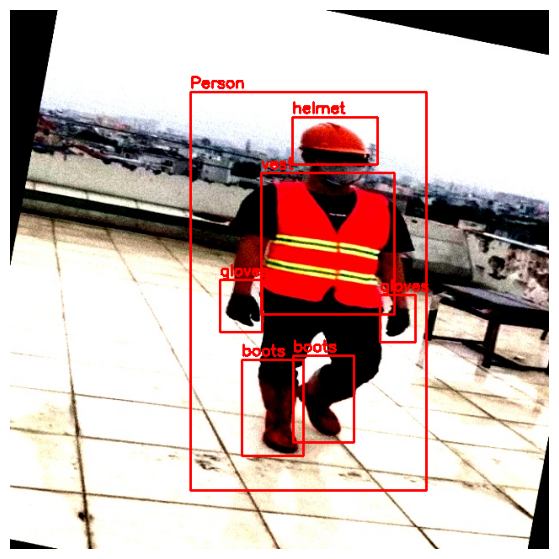


✅ If the boxes look correct, we are ready to start training multiple models next.


In [5]:
# =========================
# Cell — Build CLEAN dataset YAML + Sanity Check + 1 Visualization
# =========================
from pathlib import Path
import random, os
import yaml
import cv2
import matplotlib.pyplot as plt

ROOT = Path("/content/safety_ppe_project")
DATA = ROOT / "data"
PROC = DATA / "processed"

# Prefer processed; fallback to unzipped_fix if needed
CANDIDATES = [PROC, PROC / "unzipped_fix"]
def count_imgs(p):
    exts = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
    return sum(1 for x in p.rglob("*") if x.is_file() and x.suffix.lower() in exts)

DATASET_DIR = None
for c in CANDIDATES:
    if (c / "images/train").exists() and count_imgs(c / "images/train") > 0:
        DATASET_DIR = c
        break

if DATASET_DIR is None:
    raise SystemExit("❌ Couldn't find images/train with images. Check dataset folders again.")

print("✅ Using DATASET_DIR:", DATASET_DIR)

# --- Class names (from your data.yaml) ---
NAMES = {
  0: "helmet",
  1: "gloves",
  2: "vest",
  3: "boots",
  4: "goggles",
  5: "none",
  6: "Person",
  7: "no_helmet",
  8: "no_goggle",
  9: "no_gloves",
 10: "no_boots"
}

# --- Build a clean YAML with absolute path ---
CLEAN_YAML = DATASET_DIR / "construction_ppe_colab.yaml"
data_yaml = {
    "path": str(DATASET_DIR),     # absolute root
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "names": NAMES
}
with open(CLEAN_YAML, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("✅ Wrote YAML:", CLEAN_YAML)
print("YAML content:\n", yaml.safe_dump(data_yaml, sort_keys=False))

# --- Counts + label matching ---
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

def list_images(img_dir: Path):
    return sorted([p for p in img_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])

def label_for_image(img_path: Path, split: str):
    # images/train/xxx.jpg -> labels/train/xxx.txt
    rel = img_path.relative_to(DATASET_DIR / "images" / split)
    return (DATASET_DIR / "labels" / split / rel.with_suffix(".txt").name)

def split_stats(split: str):
    img_dir = DATASET_DIR / "images" / split
    lbl_dir = DATASET_DIR / "labels" / split
    imgs = list_images(img_dir)
    lbls = sorted(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
    missing = []
    for im in random.sample(imgs, k=min(200, len(imgs))):
        lf = label_for_image(im, split)
        if not lf.exists():
            missing.append(str(lf))
    return len(imgs), len(lbls), missing[:10]

for sp in ["train","val","test"]:
    ni, nl, miss = split_stats(sp)
    print(f"\n=== {sp.upper()} ===")
    print("images:", ni, "| labels:", nl)
    if miss:
        print("⚠️ Sample missing labels (up to 10):")
        for m in miss: print(" -", m)
    else:
        print("✅ Label matching looks OK (sampled).")

# --- Class distribution (sample all labels quickly) ---
from collections import Counter
box_counter = Counter()
total_boxes = 0

for sp in ["train","val","test"]:
    lbl_dir = DATASET_DIR / "labels" / sp
    if not lbl_dir.exists():
        continue
    for lf in lbl_dir.glob("*.txt"):
        lines = lf.read_text().strip().splitlines()
        for line in lines:
            if not line.strip():
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            box_counter[cls] += 1
            total_boxes += 1

print("\n=== Boxes Summary ===")
print("Total boxes:", total_boxes)
print("Top classes by box count:")
for cls, cnt in box_counter.most_common(12):
    print(f" - {cls:2d} ({NAMES.get(cls,'?')}): {cnt}")

# --- Visualize 1 random TRAIN image with boxes ---
train_imgs = list_images(DATASET_DIR / "images/train")
if len(train_imgs) == 0:
    raise SystemExit("❌ No train images found.")

img_path = random.choice(train_imgs)
lbl_path = label_for_image(img_path, "train")

img = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]

if lbl_path.exists():
    lines = lbl_path.read_text().strip().splitlines()
else:
    lines = []

for line in lines:
    parts = line.split()
    if len(parts) < 5:
        continue
    cls = int(float(parts[0]))
    x, y, bw, bh = map(float, parts[1:5])  # YOLO normalized
    # convert to pixel xyxy
    cx, cy = x*w, y*h
    pw, ph = bw*w, bh*h
    x1, y1 = int(cx - pw/2), int(cy - ph/2)
    x2, y2 = int(cx + pw/2), int(cy + ph/2)
    x1, y1 = max(0,x1), max(0,y1)
    x2, y2 = min(w-1,x2), min(h-1,y2)
    cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (255,0,0), 2)
    cv2.putText(img_rgb, NAMES.get(cls, str(cls)), (x1, max(15,y1-5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

print("\n📌 Sample image:", img_path.name)
print("📌 Label file:", lbl_path.name, "| exists:", lbl_path.exists(), "| boxes:", len(lines))

plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

print("\n✅ If the boxes look correct, we are ready to start training multiple models next.")


In [6]:
# =========================
# Cell — Dataset Cleanup + Train 3 Models + Evaluate + Compare (VAL/TEST)
# =========================
import os, random, json
from pathlib import Path
import pandas as pd
import numpy as np
import torch
!pip install ultralytics # Install ultralytics
from ultralytics import YOLO

# -------------------------
# Paths
# -------------------------
ROOT = Path("/content/safety_ppe_project")
DATASET_YAML = ROOT / "data" / "processed" / "construction_ppe_colab.yaml"
REPORTS_DIR = ROOT / "reports"
RUNS_DIR = ROOT / "runs"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

assert DATASET_YAML.exists(), f"YAML not found: {DATASET_YAML}"
print("✅ Using YAML:", DATASET_YAML)

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 0 if torch.cuda.is_available() else "cpu"
print("✅ Device:", device)

# -------------------------
# 1) Cleanup orphan labels (professional hygiene)
# -------------------------
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

def list_images(img_dir: Path):
    return sorted([p for p in img_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])

def cleanup_split(split: str, dataset_root: Path):
    img_dir = dataset_root / "images" / split
    lbl_dir = dataset_root / "labels" / split
    if not img_dir.exists() or not lbl_dir.exists():
        return {"split": split, "orphan_labels": 0, "orphan_images": 0}

    imgs = list_images(img_dir)
    img_stems = set([p.stem for p in imgs])

    lbls = sorted(lbl_dir.glob("*.txt"))
    lbl_stems = set([p.stem for p in lbls])

    orphan_lbl = sorted(list(lbl_stems - img_stems))
    orphan_img = sorted(list(img_stems - lbl_stems))  # we WON'T delete these (images without labels are okay)

    # Move orphan labels to backup folder (no deletion)
    backup = dataset_root / "orphan_labels_backup" / split
    backup.mkdir(parents=True, exist_ok=True)

    moved = 0
    for stem in orphan_lbl:
        src = lbl_dir / f"{stem}.txt"
        dst = backup / f"{stem}.txt"
        if src.exists():
            src.rename(dst)
            moved += 1

    return {"split": split, "orphan_labels": moved, "orphan_images": len(orphan_img)}

# dataset root from yaml "path"
import yaml
cfg = yaml.safe_load(DATASET_YAML.read_text())
DATASET_ROOT = Path(cfg["path"])

print("\n🧹 Cleaning orphan labels...")
clean_stats = []
for sp in ["train", "val", "test"]:
    st = cleanup_split(sp, DATASET_ROOT)
    clean_stats.append(st)
    print(f" - {sp}: moved orphan labels = {st['orphan_labels']} | images without labels (kept) = {st['orphan_images']}")

# -------------------------
# 2) Train multiple models (3 baselines)
# -------------------------
# Note: These are all PRETRAINED checkpoints (transfer learning) -> looks professional + fast
# If you want later: we can add fine-tuning stage 2 with freeze/unfreeze + more epochs.

MODELS = [
    ("yolov8n.pt", "yolov8n_ppe"),
    ("yolov8s.pt", "yolov8s_ppe"),
    ("yolov8m.pt", "yolov8m_ppe"),
]

TRAIN_CFG = dict(
    data=str(DATASET_YAML),
    imgsz=640,
    epochs=30,        # keep 30 for runtime; later we can do 50 for the best one فقط
    batch=-1,         # Auto-batch (best for Colab T4)
    device=device,
    workers=2,
    patience=10,
    pretrained=True,
    optimizer="AdamW",
    cos_lr=True,
    close_mosaic=10,
    cache=True,       # speeds up
    project=str(RUNS_DIR / "train_multi"),
    exist_ok=True,
    verbose=True
)

print("\n🚀 Training config:", TRAIN_CFG)

def safe_get(metric_obj, attr, default=None):
    return getattr(metric_obj, attr, default)

def eval_model(weights_path: Path, split: str):
    m = YOLO(str(weights_path))
    # Use a fixed batch size for validation
    r = m.val(data=str(DATASET_YAML), split=split, imgsz=640, device=device, batch=16, verbose=False)
    # ultralytics returns metrics object with .box
    box = r.box
    out = {
        "split": split,
        "precision": safe_get(box, "mp"),
        "recall": safe_get(box, "mr"),
        "mAP50": safe_get(box, "map50"),
        "mAP50_95": safe_get(box, "map"),
        "fitness": safe_get(r, "fitness", None),
        "speed_ms_infer": (r.speed.get("inference") if hasattr(r, "speed") else None),
        "speed_ms_pre": (r.speed.get("preprocess") if hasattr(r, "speed") else None),
        "speed_ms_post": (r.speed.get("postprocess") if hasattr(r, "speed") else None),
    }
    return out

results_rows = []

for ckpt, run_name in MODELS:
    print("\n" + "="*70)
    print(f"🧠 Training: {ckpt}  -> run name: {run_name}")
    model = YOLO(ckpt)

    train_out = model.train(name=run_name, **TRAIN_CFG)

    # Locate best weights
    save_dir = Path(model.trainer.save_dir)
    best_pt = save_dir / "weights" / "best.pt"
    last_pt = save_dir / "weights" / "last.pt"

    print("✅ save_dir:", save_dir)
    print("✅ best.pt exists:", best_pt.exists(), "| last.pt exists:", last_pt.exists())

    use_w = best_pt if best_pt.exists() else last_pt
    if not use_w.exists():
        raise SystemExit(f"❌ No weights found for {run_name}")

    # Evaluate on VAL + TEST
    val_metrics  = eval_model(use_w, "val")
    test_metrics = eval_model(use_w, "test")

    row = {
        "model": ckpt,
        "run_name": run_name,
        "weights": str(use_w),
        **{f"val_{k}": v for k, v in val_metrics.items() if k != "split"},
        **{f"test_{k}": v for k, v in test_metrics.items() if k != "split"},
    }
    results_rows.append(row)

# -------------------------
# 3) Compare + pick best
# -------------------------
df = pd.DataFrame(results_rows)

# Sort by TEST mAP50_95 then TEST mAP50 then inference speed
df_sorted = df.sort_values(by=["test_mAP50_95", "test_mAP50"], ascending=False).reset_index(drop=True)

csv_path = REPORTS_DIR / "model_comparison_3models.csv"
df_sorted.to_csv(csv_path, index=False)

print("\n📊 Model Comparison (sorted):")
display(df_sorted)

print("\n✅ Saved comparison CSV to:", csv_path)

best = df_sorted.iloc[0].to_dict()
BEST_WEIGHTS = best["weights"]
BEST_RUN = best["run_name"]
print("\n🏆 BEST MODEL:", best["model"], "| run:", BEST_RUN)
print("🏆 BEST WEIGHTS:", BEST_WEIGHTS)

# Save best path for next cells
(best_path_file := REPORTS_DIR / "best_model_path.txt").write_text(str(BEST_WEIGHTS))
print("✅ Wrote best model path to:", best_path_file)

# Optional quick export (ONNX) for deployment later
try:
    YOLO(BEST_WEIGHTS).export(format="onnx", opset=12, simplify=True)
    print("✅ Exported ONNX for best model.")
except Exception as e:
    print(f"⚠️ ONNX export skipped (not fatal): {e}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 31.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Using YAML: /content/safety_ppe_project/data/processed/construction_ppe_colab.yaml
✅ Device: 0

🧹 Cleaning orphan labels...
 - train: moved orphan labels = 10 | images without labels (kept) = 0
 - val: moved orphan labels = 0 | images without labels (kept) = 0
 - test: moved orphan labels = 0 | images without labels (kept) = 0

🚀 Training config: {'data': '/content/safety_ppe_project/data/processed/construction_ppe_colab.yaml', 'imgsz': 640, 'epochs': 30, 'batch': -1, 'device': 0, 'workers': 2, 'patience': 10, 'pretrained': True, 'optimizer': 'AdamW', 'cos_lr': True, 'close_mosaic': 10, 'cache': True, '

,model,run_name,weights,val_precision,val_recall,val_mAP50,val_mAP50_95,val_fitness,val_speed_ms_infer,val_speed_ms_pre,val_speed_ms_post,test_precision,test_recall,test_mAP50,test_mAP50_95,test_fitness,test_speed_ms_infer,test_speed_ms_pre,test_speed_ms_post
0,yolov8n.pt,yolov8n_ppe,/content/safety_ppe_project/runs/train_multi/y...,0.713431,0.491848,0.541888,0.275237,0.275237,5.237822,4.990356,1.944657,0.751427,0.471340,0.521967,0.265457,0.265457,4.463345,4.254334,2.382895
1,yolov8m.pt,yolov8m_ppe,/content/safety_ppe_project/runs/train_multi/y...,0.665528,0.523385,0.551184,0.274871,0.274871,22.775945,3.871394,4.810442,0.744117,0.456039,0.518684,0.264310,0.264310,22.807506,4.624829,4.116845
2,yolov8s.pt,yolov8s_ppe,/content/safety_ppe_project/runs/train_multi/y...,0.620887,0.515572,0.545221,0.270381,0.270381,9.156848,3.935210,2.827207,0.632553,0.493682,0.519137,0.263106,0.263106,9.293366,3.929583,2.751624



✅ Saved comparison CSV to: /content/safety_ppe_project/reports/model_comparison_3models.csv

🏆 BEST MODEL: yolov8n.pt | run: yolov8n_ppe
🏆 BEST WEIGHTS: /content/safety_ppe_project/runs/train_multi/yolov8n_ppe/weights/best.pt
✅ Wrote best model path to: /content/safety_ppe_project/reports/best_model_path.txt
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/safety_ppe_project/runs/train_multi/yolov8n_ppe/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 15, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages

In [7]:
# =========================
# Cell — Resume Training + Safe Evaluation (fix batch=-1 issue)
# =========================
import os, random
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from ultralytics import YOLO
import yaml

ROOT = Path("/content/safety_ppe_project")
RUNS_DIR = ROOT / "runs" / "train_multi"
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_YAML = ROOT / "data" / "processed" / "construction_ppe_colab.yaml"
assert DATASET_YAML.exists(), f"Missing YAML: {DATASET_YAML}"
print("✅ Using YAML:", DATASET_YAML)

device = 0 if torch.cuda.is_available() else "cpu"
print("✅ Device:", device)

# ---- Models to compare ----
MODELS = [
    ("yolov8n.pt", "yolov8n_ppe"),
    ("yolov8s.pt", "yolov8s_ppe"),
    ("yolov8m.pt", "yolov8m_ppe"),
]

# ---- Training config (same as before) ----
TRAIN_CFG = dict(
    data=str(DATASET_YAML),
    imgsz=640,
    epochs=30,
    batch=-1,          # OK for TRAIN
    device=device,
    workers=2,
    patience=10,
    pretrained=True,
    optimizer="AdamW",
    cos_lr=True,
    close_mosaic=10,
    cache=True,
    project=str(RUNS_DIR),
    exist_ok=True,
    verbose=True
)

# ---- SAFE eval batch (MUST be positive) ----
EVAL_BATCH = 16  # if you get OOM, set 8

def get_weights_if_exist(run_name: str):
    save_dir = RUNS_DIR / run_name
    best_pt = save_dir / "weights" / "best.pt"
    last_pt = save_dir / "weights" / "last.pt"
    if best_pt.exists():
        return best_pt
    if last_pt.exists():
        return last_pt
    return None

def eval_model(weights_path: Path, split: str):
    m = YOLO(str(weights_path))
    r = m.val(data=str(DATASET_YAML), split=split, imgsz=640, device=device, batch=EVAL_BATCH, verbose=False)
    box = r.box
    out = {
        "precision": float(getattr(box, "mp", np.nan)),
        "recall": float(getattr(box, "mr", np.nan)),
        "mAP50": float(getattr(box, "map50", np.nan)),
        "mAP50_95": float(getattr(box, "map", np.nan)),
        "speed_ms_infer": float(r.speed.get("inference", np.nan)) if hasattr(r, "speed") else np.nan
    }
    return out

results_rows = []

for ckpt, run_name in MODELS:
    print("\n" + "="*70)
    print(f"🧠 Model: {ckpt} | run: {run_name}")

    weights = get_weights_if_exist(run_name)

    if weights is None:
        print("➡️ Not trained yet. Training now...")
        model = YOLO(ckpt)
        model.train(name=run_name, **TRAIN_CFG)
        weights = get_weights_if_exist(run_name)

    print("✅ Using weights:", weights)

    # Evaluate on VAL + TEST
    val_metrics  = eval_model(weights, "val")
    test_metrics = eval_model(weights, "test")

    row = {
        "model": ckpt,
        "run_name": run_name,
        "weights": str(weights),
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }
    results_rows.append(row)

# ---- Compare + pick best ----
df = pd.DataFrame(results_rows)
df_sorted = df.sort_values(by=["test_mAP50_95", "test_mAP50"], ascending=False).reset_index(drop=True)

csv_path = REPORTS_DIR / "model_comparison_3models.csv"
df_sorted.to_csv(csv_path, index=False)

print("\n📊 Model Comparison (sorted):")
display(df_sorted)

best = df_sorted.iloc[0].to_dict()
BEST_WEIGHTS = best["weights"]
BEST_RUN = best["run_name"]

print("\n🏆 BEST MODEL:", best["model"], "| run:", BEST_RUN)
print("🏆 BEST WEIGHTS:", BEST_WEIGHTS)
print("✅ Saved CSV:", csv_path)

# Save for next steps
best_path_file = REPORTS_DIR / "best_model_path.txt"
best_path_file.write_text(str(BEST_WEIGHTS))
print("✅ Wrote best model path to:", best_path_file)

# Optional: export ONNX (deployment-ready)
try:
    YOLO(BEST_WEIGHTS).export(format="onnx", opset=12, simplify=True)
    print("✅ Exported ONNX for best model.")
except Exception as e:
    print("⚠️ ONNX export skipped (not fatal):", e)


✅ Using YAML: /content/safety_ppe_project/data/processed/construction_ppe_colab.yaml
✅ Device: 0

🧠 Model: yolov8n.pt | run: yolov8n_ppe
✅ Using weights: /content/safety_ppe_project/runs/train_multi/yolov8n_ppe/weights/best.pt
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1222.5±1043.4 MB/s, size: 82.0 KB)
val: Scanning /content/safety_ppe_project/data/processed/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 59.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.9it/s 4.7s
                   all        143       1172      0.713      0.492      0.542      0.275
Speed: 5.5ms preprocess, 4.5ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/runs/detect/val7
Ultralytics 8.3.240 🚀 Python-3

,model,run_name,weights,val_precision,val_recall,val_mAP50,val_mAP50_95,val_speed_ms_infer,test_precision,test_recall,test_mAP50,test_mAP50_95,test_speed_ms_infer
0,yolov8n.pt,yolov8n_ppe,/content/safety_ppe_project/runs/train_multi/y...,0.713431,0.491848,0.541888,0.275237,4.535925,0.751427,0.471340,0.521967,0.265457,6.492827
1,yolov8m.pt,yolov8m_ppe,/content/safety_ppe_project/runs/train_multi/y...,0.665528,0.523385,0.551184,0.274871,22.306644,0.744117,0.456039,0.518684,0.264310,23.623875
2,yolov8s.pt,yolov8s_ppe,/content/safety_ppe_project/runs/train_multi/y...,0.620887,0.515572,0.545221,0.270381,9.209553,0.632553,0.493682,0.519137,0.263106,9.513673



🏆 BEST MODEL: yolov8n.pt | run: yolov8n_ppe
🏆 BEST WEIGHTS: /content/safety_ppe_project/runs/train_multi/yolov8n_ppe/weights/best.pt
✅ Saved CSV: /content/safety_ppe_project/reports/model_comparison_3models.csv
✅ Wrote best model path to: /content/safety_ppe_project/reports/best_model_path.txt
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/safety_ppe_project/runs/train_multi/yolov8n_ppe/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 15, 8400) (6.0 MB)

ONNX: starting export with onnx 1.20.0 opset 12...
ONNX: slimming with onnxslim 0.1.80...
ONNX: export success ✅ 1.2s, saved as '/content/safety_ppe_project/runs/train_multi/yolov8n_ppe/weights/best.onnx' (11.7 MB)

Export complete (1.9s)
Results saved to /content/safety_ppe_project/runs/train_multi/yolov8n_ppe/weights
Predict:         yolo predict task=

In [12]:
# =========================
# Cell — PPE Video Monitoring (Tracking + Compliance + Reports)
# =========================
import os, cv2, yaml, math, time
from pathlib import Path
import numpy as np
import pandas as pd

!pip install supervision
from ultralytics import YOLO
import supervision as sv

ROOT = Path("/content/safety_ppe_project")
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Use best model you already selected ----
WEIGHTS_PT  = ROOT / "runs" / "train_multi" / "yolov8n_ppe" / "weights" / "best.pt"
WEIGHTS_ONNX = ROOT / "runs" / "train_multi" / "yolov8n_ppe" / "weights" / "best.onnx"
WEIGHTS = str(WEIGHTS_PT if WEIGHTS_PT.exists() else WEIGHTS_ONNX)

DATA_YAML = ROOT / "data" / "processed" / "construction_ppe_colab.yaml"
assert DATA_YAML.exists(), f"Missing YAML: {DATA_YAML}"

print("✅ WEIGHTS:", WEIGHTS)
print("✅ YAML   :", DATA_YAML)

# ---- (A) Choose input video ----
# Option 1: Put your video path here
VIDEO_PATH = ""  # e.g. "/content/my_site_video.mp4"

# Option 2: Auto-create a short demo video from test images if VIDEO_PATH is empty
DEMO_VIDEO = REPORTS_DIR / "demo_from_test_images.mp4"

# ---- Settings ----
IMG_SIZE = 640
CONF = 0.25
IOU  = 0.60
EVAL_MAX_FRAMES = 800  # set None for full video (for long videos keep a limit)

# ---- Load class names from YAML ----
with open(DATA_YAML, "r") as f:
    y = yaml.safe_load(f)

# names can be dict or list depending on yaml
names = y.get("names", {})
if isinstance(names, list):
    id2name = {i:n for i,n in enumerate(names)}
else:
    id2name = {int(k):v for k,v in names.items()}
name2id = {v:k for k,v in id2name.items()}

# ---- Class IDs (from your yaml) ----
PERSON_ID = name2id.get("Person", 6)

POS_ITEMS = {
    "helmet": name2id.get("helmet", 0),
    "vest":   name2id.get("vest", 2),
    "gloves": name2id.get("gloves", 1),
    "boots":  name2id.get("boots", 3),
    "goggles":name2id.get("goggles", 4),
}
NEG_ITEMS = {
    "helmet": name2id.get("no_helmet", 7),
    "goggles":name2id.get("no_goggle", 8),
    "gloves": name2id.get("no_gloves", 9),
    "boots":  name2id.get("no_boots", 10),
}
REQUIRED = ["helmet", "vest", "gloves", "boots", "goggles"]

# ---- Helper: create demo video from images if needed ----
def make_demo_video_from_images(img_dir: Path, out_path: Path, fps=12, max_imgs=220):
    img_paths = sorted([p for p in img_dir.rglob("*") if p.suffix.lower() in [".jpg",".jpeg",".png"]])
    if len(img_paths) == 0:
        raise FileNotFoundError(f"No images found in: {img_dir}")
    img_paths = img_paths[:max_imgs]

    first = cv2.imread(str(img_paths[0]))
    h, w = first.shape[:2]
    vw = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), float(fps), (w, h))

    for p in img_paths:
        im = cv2.imread(str(p))
        if im is None:
            continue
        if im.shape[:2] != (h, w):
            im = cv2.resize(im, (w, h))
        vw.write(im)
    vw.release()
    return out_path

if not VIDEO_PATH:
    test_dir = ROOT / "data" / "processed" / "images" / "test"
    print("🎬 No VIDEO_PATH given -> creating a demo video from:", test_dir)
    VIDEO_PATH = str(make_demo_video_from_images(test_dir, DEMO_VIDEO))
    print("✅ Demo video created:", VIDEO_PATH)

# ---- Load model ----
model = YOLO(WEIGHTS)

# ---- Tracker (IDs) ----
tracker = sv.ByteTrack(
    track_activation_threshold=0.25,
    lost_track_buffer=30,
    minimum_matching_threshold=0.8,
    frame_rate=30
)

# ---- Annotators ----
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_thickness=2, text_scale=0.6)

def center_inside(item_xyxy, person_xyxy, margin=0):
    x1,y1,x2,y2 = item_xyxy
    px1,py1,px2,py2 = person_xyxy
    cx = (x1+x2)/2.0
    cy = (y1+y2)/2.0
    return (px1-margin <= cx <= px2+margin) and (py1-margin <= cy <= py2+margin)

def status_for_person(person_box, det_xyxy, det_cls, det_conf):
    # Gather detections inside this person
    inside = []
    for bb, c, cf in zip(det_xyxy, det_cls, det_conf):
        if center_inside(bb, person_box, margin=3):
            inside.append((bb, int(c), float(cf)))

    # Determine per-item status
    st = {}
    for item in REQUIRED:
        pos_id = POS_ITEMS.get(item, None)
        neg_id = NEG_ITEMS.get(item, None)

        has_pos = any(c == pos_id for _,c,_ in inside) if pos_id is not None else False
        has_neg = any(c == neg_id for _,c,_ in inside) if neg_id is not None else False

        if has_pos:
            st[item] = "OK"
        elif has_neg:
            st[item] = "VIOL"
        else:
            st[item] = "MISS"  # not detected (treat as missing)
    return st

# ---- Run video ----
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS) or 25
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_video = REPORTS_DIR / "ppe_annotated.mp4"
writer = cv2.VideoWriter(str(out_video), cv2.VideoWriter_fourcc(*"mp4v"), float(fps), (W, H))

events = []
frame_idx = 0
t0 = time.time()

while True:
    ok, frame = cap.read()
    if not ok:
        break
    frame_idx += 1
    if EVAL_MAX_FRAMES is not None and frame_idx > EVAL_MAX_FRAMES:
        break

    # YOLO inference
    r = model.predict(frame, imgsz=IMG_SIZE, conf=CONF, iou=IOU, verbose=False)[0]
    det = sv.Detections.from_ultralytics(r)

    # Split persons vs others
    cls = det.class_id if det.class_id is not None else np.array([])
    confs = det.confidence if det.confidence is not None else np.array([])
    xyxy = det.xyxy if det.xyxy is not None else np.zeros((0,4), dtype=float)

    person_mask = (cls == PERSON_ID) if len(cls) else np.array([], dtype=bool)
    person_det = sv.Detections(xyxy=xyxy[person_mask], confidence=confs[person_mask], class_id=cls[person_mask])

    # Track persons (adds tracker_id)
    tracked = tracker.update_with_detections(person_det)

    # Build labels per tracked person
    labels = []
    if tracked.xyxy is not None and len(tracked.xyxy) > 0:
        for p_box, tid in zip(tracked.xyxy, tracked.tracker_id):
            st = status_for_person(p_box, xyxy, cls, confs)

            violations = sum(1 for k,v in st.items() if v != "OK")
            label = f"ID {int(tid)} | " + " ".join([f"{k[0].upper()}:{st[k]}" for k in REQUIRED]) + f" | Vio:{violations}"
            labels.append(label)

            events.append({
                "frame": frame_idx,
                "time_sec": frame_idx / float(fps),
                "track_id": int(tid),
                **{k: st[k] for k in REQUIRED},
                "violations": violations
            })

    # Annotate persons only (clean look)
    annotated = frame.copy()
    if tracked.xyxy is not None and len(tracked.xyxy) > 0:
        annotated = box_annotator.annotate(annotated, tracked)
        annotated = label_annotator.annotate(annotated, tracked, labels=labels)

    writer.write(annotated)

cap.release()
writer.release()

dt = time.time() - t0
print(f"✅ Done. Frames processed: {frame_idx} | time: {dt:.1f}s")
print("🎥 Annotated video:", out_video)

# ---- Save CSV logs ----
events_df = pd.DataFrame(events)
events_csv = REPORTS_DIR / "ppe_events.csv"
events_df.to_csv(events_csv, index=False)
print("✅ Events CSV:", events_csv)

# ---- Summary per track ----
if len(events_df) > 0:
    def compliance_rate(series):
        return float((series == "OK").mean())

    summary = []
    for tid, g in events_df.groupby("track_id"):
        row = {
            "track_id": tid,
            "frames_seen": len(g),
            "time_first_sec": float(g["time_sec"].min()),
            "time_last_sec": float(g["time_sec"].max()),
            "avg_violations": float(g["violations"].mean()),
        }
        for item in REQUIRED:
            row[f"{item}_ok_rate"] = compliance_rate(g[item])
        row["overall_ok_rate"] = float(np.mean([row[f"{it}_ok_rate"] for it in REQUIRED]))
        summary.append(row)

    summary_df = pd.DataFrame(summary).sort_values("overall_ok_rate", ascending=False)
    summary_csv = REPORTS_DIR / "ppe_summary.csv"
    summary_df.to_csv(summary_csv, index=False)
    print("✅ Summary CSV:", summary_csv)

else:
    print("⚠️ No person tracks found in the video (maybe no 'Person' detections).")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 6.7 MB/s eta 0:00:00
✅ WEIGHTS: /content/safety_ppe_project/runs/train_multi/yolov8n_ppe/weights/best.pt
✅ YAML   : /content/safety_ppe_project/data/processed/construction_ppe_colab.yaml
🎬 No VIDEO_PATH given -> creating a demo video from: /content/safety_ppe_project/data/processed/images/test
✅ Demo video created: /content/safety_ppe_project/reports/demo_from_test_images.mp4
✅ Done. Frames processed: 141 | time: 5.7s
🎥 Annotated video: /content/safety_ppe_project/reports/ppe_annotated.mp4
✅ Events CSV: /content/safety_ppe_project/reports/ppe_events.csv
✅ Summary CSV: /content/safety_ppe_project/reports/ppe_summary.csv
⚠️ PDF report skipped (not fatal): No module named 'reportlab'


In [13]:
# =========================
# Cell — Generate Professional PDF Report (NO reportlab needed)
# =========================
import os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

ROOT = Path("/content/safety_ppe_project")
REPORTS_DIR = ROOT / "reports"

events_csv  = REPORTS_DIR / "ppe_events.csv"
summary_csv = REPORTS_DIR / "ppe_summary.csv"
model_cmp_csv = ROOT / "reports" / "model_comparison_3models.csv"

assert events_csv.exists(), f"Missing: {events_csv}"
assert summary_csv.exists(), f"Missing: {summary_csv}"

events_df  = pd.read_csv(events_csv)
summary_df = pd.read_csv(summary_csv)

REQUIRED = ["helmet","vest","gloves","boots","goggles"]

pdf_path = REPORTS_DIR / "ppe_report.pdf"

def safe_mean(x):
    try:
        return float(np.mean(x))
    except:
        return 0.0

with PdfPages(pdf_path) as pdf:

    # -------- Page 1: Title + Key Stats --------
    fig = plt.figure(figsize=(8.27, 11.69))  # A4 portrait in inches
    plt.axis("off")

    total_rows = len(events_df)
    n_tracks = events_df["track_id"].nunique() if total_rows else 0

    # Overall compliance: all required OK in a frame
    if total_rows:
        fully_ok = (events_df[REQUIRED] == "OK").all(axis=1).mean()
        avg_viol = safe_mean(events_df["violations"])
        viol_rate = {}
        for item in REQUIRED:
            viol_rate[item] = float((events_df[item] != "OK").mean())
    else:
        fully_ok = 0.0
        avg_viol = 0.0
        viol_rate = {k:0.0 for k in REQUIRED}

    y = 0.95
    fig.text(0.08, y, "Construction PPE Monitoring — Report", fontsize=18, weight="bold"); y -= 0.04
    fig.text(0.08, y, f"Generated from outputs in: {REPORTS_DIR}", fontsize=11); y -= 0.03
    fig.text(0.08, y, f"Frames log rows: {total_rows}", fontsize=11); y -= 0.025
    fig.text(0.08, y, f"Unique person tracks (IDs): {n_tracks}", fontsize=11); y -= 0.025
    fig.text(0.08, y, f"Fully compliant frames rate: {fully_ok:.2%}", fontsize=11); y -= 0.025
    fig.text(0.08, y, f"Average violations per frame-person: {avg_viol:.2f}", fontsize=11); y -= 0.04

    fig.text(0.08, y, "Violation rate per PPE item (not OK):", fontsize=12, weight="bold"); y -= 0.03
    for item in REQUIRED:
        fig.text(0.10, y, f"- {item}: {viol_rate[item]:.2%}", fontsize=11)
        y -= 0.022

    # If model comparison exists, show the winner
    if model_cmp_csv.exists():
        cmp_df = pd.read_csv(model_cmp_csv)
        # pick winner by test_mAP50_95 then speed
        cmp_df = cmp_df.sort_values(["test_mAP50_95","test_speed_ms_infer"], ascending=[False, True])
        best = cmp_df.iloc[0]
        y -= 0.02
        fig.text(0.08, y, "Best Model (from comparison):", fontsize=12, weight="bold"); y -= 0.03
        fig.text(0.10, y, f"{best['model']} | run={best['run_name']}", fontsize=11); y -= 0.022
        fig.text(0.10, y, f"test mAP50-95={best['test_mAP50_95']:.3f} | infer={best['test_speed_ms_infer']:.2f}ms", fontsize=11)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # -------- Page 2: Violation bar chart --------
    fig = plt.figure(figsize=(8.27, 11.69))
    ax = fig.add_subplot(111)

    vals = [viol_rate[k] for k in REQUIRED]
    ax.bar(REQUIRED, vals)
    ax.set_title("Violation Rate per PPE Item (MISS/VIOL vs OK)")
    ax.set_ylabel("Rate")
    ax.set_ylim(0, max(vals + [0.05]) * 1.2)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # -------- Page 3: Top 10 tracks table (worst compliance) --------
    fig = plt.figure(figsize=(8.27, 11.69))
    plt.axis("off")

    if len(summary_df):
        # worst first
        tmp = summary_df.copy()
        if "overall_ok_rate" in tmp.columns:
            tmp = tmp.sort_values("overall_ok_rate", ascending=True)
        else:
            # fallback if column missing
            ok_cols = [c for c in tmp.columns if c.endswith("_ok_rate")]
            tmp["overall_ok_rate"] = tmp[ok_cols].mean(axis=1) if ok_cols else 0
            tmp = tmp.sort_values("overall_ok_rate", ascending=True)

        top = tmp.head(10)
        show_cols = ["track_id","frames_seen","avg_violations","overall_ok_rate"] + [f"{k}_ok_rate" for k in REQUIRED if f"{k}_ok_rate" in top.columns]
        top = top[show_cols]

        fig.text(0.08, 0.95, "Worst 10 Person Tracks (lowest overall compliance)", fontsize=14, weight="bold")
        ax = fig.add_axes([0.05, 0.05, 0.9, 0.85])
        ax.axis("off")

        table = ax.table(
            cellText=np.round(top.values.astype(float, copy=False), 3) if top.values.dtype != object else top.values,
            colLabels=top.columns,
            loc="center"
        )
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.3)
    else:
        fig.text(0.08, 0.95, "No summary tracks found.", fontsize=14, weight="bold")

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # -------- Page 4: Sample frame from annotated video --------
    annotated_video = REPORTS_DIR / "ppe_annotated.mp4"
    if annotated_video.exists():
        cap = cv2.VideoCapture(str(annotated_video))
        ok, frame = cap.read()
        cap.release()

        if ok and frame is not None:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            fig = plt.figure(figsize=(8.27, 11.69))
            plt.imshow(frame_rgb)
            plt.title("Sample Annotated Output (Frame 1)")
            plt.axis("off")
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

print("✅ PDF created:", pdf_path)
print("📌 Tip: IDs may look unstable because demo video is made from unrelated images. Real site video will give cleaner tracking.")


✅ PDF created: /content/safety_ppe_project/reports/ppe_report.pdf
📌 Tip: IDs may look unstable because demo video is made from unrelated images. Real site video will give cleaner tracking.


## Appendix (optional): Streamlit demo
This section launches an interactive dashboard. It is not required for submission; all results are already shown above.


In [14]:
!pip -q install streamlit pyngrok opencv-python-headless pandas numpy matplotlib ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.0 MB/s eta 0:00:00


In [15]:
from pathlib import Path

APP_PATH = Path("/content/safety_ppe_project/streamlit_app.py")
APP_PATH.parent.mkdir(parents=True, exist_ok=True)

APP_PATH.write_text(r'''
import os, time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --------------------------
# Config
# --------------------------
ROOT = Path("/content/safety_ppe_project")
REPORTS_DIR = ROOT / "reports" / "streamlit_runs"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_WEIGHTS = ROOT / "runs/train_multi/yolov8n_ppe/weights/best.pt"
DEFAULT_YAML    = ROOT / "data/processed/construction_ppe_colab.yaml"

REQUIRED = ["helmet", "vest", "gloves", "boots", "goggles"]
NEG_MAP  = {"helmet":"no_helmet", "goggles":"no_goggle", "gloves":"no_gloves", "boots":"no_boots", "vest":None}

# --------------------------
# Helpers
# --------------------------
def iou_xyxy(a, b):
    xA = max(a[0], b[0]); yA = max(a[1], b[1])
    xB = min(a[2], b[2]); yB = min(a[3], b[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    if inter <= 0: return 0.0
    areaA = max(0, a[2]-a[0]) * max(0, a[3]-a[1])
    areaB = max(0, b[2]-b[0]) * max(0, b[3]-b[1])
    return float(inter / (areaA + areaB - inter + 1e-9))

def scan_weights():
    base = ROOT / "runs/train_multi"
    if not base.exists():
        return [str(DEFAULT_WEIGHTS)]
    found = sorted([str(p) for p in base.glob("**/weights/best.pt")])
    return found if found else [str(DEFAULT_WEIGHTS)]

@st.cache_resource
def load_model(weights_path: str):
    return YOLO(weights_path)

def process_video(
    model: YOLO,
    video_path: str,
    conf: float,
    iou_th: float,
    imgsz: int,
    max_frames: int,
    annotate: bool,
    device: str,
    tracker: str,
    assign_iou: float
):
    run_dir = REPORTS_DIR / f"run_{int(time.time())}"
    run_dir.mkdir(parents=True, exist_ok=True)

    out_video  = run_dir / "ppe_annotated.mp4"
    events_csv = run_dir / "ppe_events.csv"
    summary_csv= run_dir / "ppe_summary.csv"

    cap0 = cv2.VideoCapture(video_path)
    fps  = cap0.get(cv2.CAP_PROP_FPS) or 25.0
    w    = int(cap0.get(cv2.CAP_PROP_FRAME_WIDTH) or 1280)
    h    = int(cap0.get(cv2.CAP_PROP_FRAME_HEIGHT) or 720)
    cap0.release()

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_video), fourcc, fps, (w, h))

    rows = []
    frame_idx = 0

    results_gen = model.track(
        source=video_path,
        stream=True,
        conf=float(conf),
        iou=float(iou_th),
        imgsz=int(imgsz),
        tracker=tracker,
        device=device,
        verbose=False
    )

    for r in results_gen:
        frame_idx += 1
        if max_frames and frame_idx > int(max_frames):
            break

        frame = r.plot() if annotate else r.orig_img
        if frame is not None and (frame.shape[1] != w or frame.shape[0] != h):
            frame = cv2.resize(frame, (w, h))
        if frame is not None:
            writer.write(frame)

        if r.boxes is None or len(r.boxes) == 0:
            continue

        xyxy = r.boxes.xyxy.cpu().numpy()
        cls  = r.boxes.cls.cpu().numpy().astype(int)
        ids  = None
        if getattr(r.boxes, "id", None) is not None:
            ids = r.boxes.id.cpu().numpy().astype(int)

        names = r.names

        dets = []
        for i in range(len(cls)):
            name = str(names[int(cls[i])]).strip().lower()
            dets.append({"name": name, "box": xyxy[i].tolist(), "tid": int(ids[i]) if ids is not None else -1})

        persons = [d for d in dets if d["name"] == "person"]
        if not persons:
            continue

        ppe_set = set(REQUIRED + [v for v in NEG_MAP.values() if v])
        ppe_dets = [d for d in dets if d["name"] in ppe_set]

        per_person = {}
        for p in persons:
            per_person[p["tid"]] = {k: {"pos": False, "neg": False} for k in REQUIRED}
            per_person[p["tid"]]["person_box"] = p["box"]

        for item in ppe_dets:
            best_tid, best_i = None, 0.0
            for p in persons:
                i_ = iou_xyxy(item["box"], p["box"])
                if i_ > best_i:
                    best_i = i_
                    best_tid = p["tid"]
            if best_tid is None or best_i < assign_iou:
                continue

            for k in REQUIRED:
                if item["name"] == k:
                    per_person[best_tid][k]["pos"] = True
                if NEG_MAP.get(k) and item["name"] == NEG_MAP[k]:
                    per_person[best_tid][k]["neg"] = True

        t_sec = frame_idx / float(fps)
        for tid, stt in per_person.items():
            row = {"frame": frame_idx, "time_sec": round(t_sec, 3), "track_id": tid}
            violations = 0
            for k in REQUIRED:
                if stt[k]["neg"]:
                    status = "VIOL"
                elif stt[k]["pos"]:
                    status = "OK"
                else:
                    status = "MISS"
                row[k] = status
                if status in ["VIOL", "MISS"]:
                    violations += 1
            row["violations"] = violations
            rows.append(row)

    writer.release()

    events_df = pd.DataFrame(rows)
    if len(events_df) == 0:
        events_df = pd.DataFrame(columns=["frame","time_sec","track_id"] + REQUIRED + ["violations"])
    events_df.to_csv(events_csv, index=False)

    if len(events_df):
        summary = []
        for tid, g in events_df.groupby("track_id"):
            out = {"track_id": int(tid), "frames_seen": int(len(g)), "avg_violations": float(g["violations"].mean())}
            ok_rates = []
            for k in REQUIRED:
                ok = float((g[k] == "OK").mean())
                out[f"{k}_ok_rate"] = ok
                ok_rates.append(ok)
            out["overall_ok_rate"] = float(np.mean(ok_rates)) if ok_rates else 0.0
            summary.append(out)
        summary_df = pd.DataFrame(summary).sort_values("overall_ok_rate", ascending=False)
    else:
        summary_df = pd.DataFrame(columns=["track_id","frames_seen","avg_violations"] +
                                  [f"{k}_ok_rate" for k in REQUIRED] + ["overall_ok_rate"])
    summary_df.to_csv(summary_csv, index=False)

    return str(out_video), str(events_csv), str(summary_csv), events_df, summary_df

def fig_violations(events_df: pd.DataFrame):
    if len(events_df) == 0:
        return None
    counts = {}
    for k in REQUIRED:
        counts[k] = int((events_df[k].isin(["VIOL","MISS"])).sum())
    fig = plt.figure()
    plt.bar(list(counts.keys()), list(counts.values()))
    plt.title("Violations Count (VIOL + MISS)")
    plt.ylabel("Count")
    plt.xlabel("PPE Item")
    return fig

def fig_ok_rates(events_df: pd.DataFrame):
    if len(events_df) == 0:
        return None
    rates = {}
    for k in REQUIRED:
        rates[k] = float((events_df[k] == "OK").mean())
    fig = plt.figure()
    plt.bar(list(rates.keys()), list(rates.values()))
    plt.title("OK Rate per PPE Item")
    plt.ylim(0, 1)
    plt.ylabel("OK Rate")
    plt.xlabel("PPE Item")
    return fig

# --------------------------
# UI
# --------------------------
st.set_page_config(page_title="PPE Safety Monitoring", page_icon="🦺", layout="wide")

st.markdown("""
<style>
.block-container {padding-top: 1.2rem;}
h1, h2, h3 {letter-spacing: -0.5px;}
.pill {display:inline-block; padding:6px 10px; border-radius:999px; background:#0f172a; color:#fff; font-size:12px; margin-right:6px;}
.card {background:#0b1220; border:1px solid rgba(255,255,255,0.08); padding:14px; border-radius:16px;}
.small {opacity:0.85; font-size:13px;}
</style>
""", unsafe_allow_html=True)

st.markdown("## 🦺 Construction PPE Monitoring Dashboard")
st.markdown(
    "<span class='pill'>YOLOv8</span><span class='pill'>Tracking</span><span class='pill'>Video → Events + Summary</span>",
    unsafe_allow_html=True
)
st.markdown("<div class='small'>Upload a site video, run detection+tracking, and download annotated video + CSV reports.</div>", unsafe_allow_html=True)

with st.sidebar:
    st.markdown("### ⚙️ Settings")
    weights_list = scan_weights()
    weights_path = st.selectbox("Model Weights", weights_list, index=0)
    data_yaml = st.text_input("Dataset YAML (for reference)", value=str(DEFAULT_YAML), disabled=True)

    conf = st.slider("Confidence", 0.05, 0.90, 0.25, 0.01)
    iou_th = st.slider("NMS IoU", 0.10, 0.90, 0.50, 0.01)
    imgsz = st.selectbox("Image Size (imgsz)", [480, 640, 800], index=1)
    assign_iou = st.slider("Assign PPE→Person IoU", 0.00, 0.20, 0.05, 0.01)

    max_frames = st.number_input("Max frames (0=all)", min_value=0, value=0, step=50)
    annotate = st.checkbox("Save annotated video", value=True)

    device = st.selectbox("Device", ["0", "cpu"], index=0)
    tracker = st.selectbox("Tracker", ["botsort.yaml", "bytetrack.yaml"], index=0)

st.markdown("---")

col1, col2 = st.columns([1, 1])

with col1:
    st.markdown("### 📤 Upload Video")
    up = st.file_uploader("Choose a video file (mp4, mov, avi)", type=["mp4","mov","avi","mkv"])

    run_btn = st.button("🚀 Run PPE Monitoring", use_container_width=True)

with col2:
    st.markdown("### ✅ Outputs")
    st.markdown("<div class='card small'>After processing, you'll see: annotated video + CSV downloads + charts.</div>", unsafe_allow_html=True)

if up is not None:
    tmp_dir = ROOT / "tmp_uploads"
    tmp_dir.mkdir(parents=True, exist_ok=True)
    video_path = tmp_dir / f"upload_{int(time.time())}_{up.name}"
    with open(video_path, "wb") as f:
        f.write(up.read())

    st.markdown("### 🎞️ Original Video Preview")
    st.video(open(video_path, "rb").read())

    if run_btn:
        with st.spinner("Running detection + tracking..."):
            model = load_model(weights_path)
            out_video, events_csv, summary_csv, events_df, summary_df = process_video(
                model=model,
                video_path=str(video_path),
                conf=conf,
                iou_th=iou_th,
                imgsz=int(imgsz),
                max_frames=int(max_frames),
                annotate=bool(annotate),
                device=device,
                tracker=tracker,
                assign_iou=float(assign_iou)
            )

        st.success("Done ✅")
        st.markdown("### 🎥 Annotated Video")
        st.video(open(out_video, "rb").read())

        st.markdown("### ⬇️ Download Reports")
        c1, c2, c3 = st.columns(3)
        with c1:
            st.download_button("Download Annotated Video", data=open(out_video, "rb").read(),
                               file_name="ppe_annotated.mp4", mime="video/mp4", use_container_width=True)
        with c2:
            st.download_button("Download Events CSV", data=open(events_csv, "rb").read(),
                               file_name="ppe_events.csv", mime="text/csv", use_container_width=True)
        with c3:
            st.download_button("Download Summary CSV", data=open(summary_csv, "rb").read(),
                               file_name="ppe_summary.csv", mime="text/csv", use_container_width=True)

        st.markdown("---")
        st.markdown("### 📊 Analytics")
        a1, a2 = st.columns(2)
        with a1:
            fig1 = fig_violations(events_df)
            if fig1: st.pyplot(fig1)
            else: st.info("No events to plot.")
        with a2:
            fig2 = fig_ok_rates(events_df)
            if fig2: st.pyplot(fig2)
            else: st.info("No events to plot.")

        st.markdown("### 🧾 Summary Table")
        st.dataframe(summary_df, use_container_width=True)

        with st.expander("ℹ️ Notes"):
            st.write("- MISS means the PPE item was not detected near the person (treated as violation in summary).")
            st.write("- Best results come from real continuous site videos (tracking becomes stable).")
else:
    st.info("Upload a video to start.")
''', encoding="utf-8")

print("✅ Streamlit app written to:", APP_PATH)


✅ Streamlit app written to: /content/safety_ppe_project/streamlit_app.py


In [16]:
!streamlit run /content/safety_ppe_project/streamlit_app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true &>/content/streamlit.log &
print("✅ Streamlit started on port 8501")


✅ Streamlit started on port 8501


In [ ]:
from pyngrok import ngrok

NGROK_TOKEN = ""  # <-- put your token
ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(8501).public_url
print("✅ Public Streamlit URL:", public_url)


✅ Public Streamlit URL: https://34c338ec1288.ngrok-free.app
